# Debugging splice junction modeling

## imports

In [1]:
import os
import yaml
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

FIGS_DIR = os.path.join("pdfs","debug_junctions")
os.makedirs(FIGS_DIR, exist_ok=True)

## data

In [2]:
# paths

ROOT = ".."
RAW_DIR = os.path.join(ROOT,"data","raw")
RESULTS_DIR = os.path.join(ROOT,"results")

config = yaml.safe_load(open(os.path.join(ROOT,"config","config.yaml"),"r"))
SINGLE_DIR = config["preprocessing"]["overfitting"]["single"]["output_dir"]
SAMPLES = config["preprocessing"]["overfitting"]["samples"]

interval_file = os.path.join(ROOT, SINGLE_DIR, "medium.bed")

raw_files = {
    s: os.path.join(ROOT, config["rnaseq"]["sf3b1mut"]["path"], "STAR", s, "paper_pass.SJ.out.tab")
    for s in SAMPLES
}

pretrained_dir = os.path.join(ROOT, SINGLE_DIR, "medium")
pretrained_file = os.path.join(pretrained_dir, "splice_junctions_annotated.npz")
metadata_file = os.path.join(pretrained_dir, "metadata.json")

OUTPUT_DIR = "results/finetuning/alphagenome_pytorch/overfitting/single"
finetuned_file = os.path.join(ROOT, OUTPUT_DIR, "medium", "debug_splice_junctions__truncrope__origloss__annotated__pretrinit__bfloat16", "splice_junctions_annotated.npz")

In [3]:
# loads

import json

interval = pd.read_table(
    interval_file, header=None, names=["chrom", "start", "end"],
)

chrom_oi = interval["chrom"].iloc[0]
start_oi = interval["start"].iloc[0]
end_oi = interval["end"].iloc[0]
seq_len = end_oi - start_oi

with open(metadata_file) as fh:
    meta = json.load(fh)
padded_start = meta["padded_start"]

pretrained = np.load(pretrained_file)

raw = pd.concat(
    [
        pd.read_table(
            f,
            header=None,
            names=[
                "chrom",
                "intron_start",
                "intron_end",
                "strand_code",
                "intron_motif",
                "annotated",
                "n_uniquely_mapped_reads",
                "n_multi_mapped_reads",
                "max_overhang",
            ],
        )
        .assign(
            sample=s,
            exon_start=lambda d: d["intron_start"] - 1,
            exon_end=lambda d: d["intron_end"] + 1,
            strand=lambda d: d["strand_code"].astype(str).map(
                {"0": ".", "1": "+", "2": "-"}
            ).fillna("."),
            count=lambda d: pd.to_numeric(
                d["n_uniquely_mapped_reads"], errors="coerce"
            )
        )
        .query(
            "chrom.str.contains('chr') & strand.isin(['+','-']) & count >= 1"
        )
        for s, f in raw_files.items()
    ],
    ignore_index=True
)

finetuned = np.load(finetuned_file)

## contents

In [4]:
print(pretrained.files)
print(pretrained["junction_positions"].shape)
print(pretrained["junction_counts"].shape)

['junction_positions', 'junction_counts']
(4, 512)
(512, 512, 734)


In [5]:
print(finetuned.files)
print(finetuned["junction_positions"].shape)
print(finetuned["junction_counts"].shape)

['junction_positions', 'junction_counts']
(4, 512)
(512, 512, 4)


## preprocess raw junctions

In [6]:
def normalize_junctions(junc_df: pd.DataFrame) -> pd.DataFrame:
    df = junc_df.copy()

    # Step 1: CPM normalize
    total_reads = df["count"].sum()
    if total_reads > 0:
        df["cpm"] = (df["count"] / total_reads) * 1e6
    else:
        return df  # All zeros, return as-is

    # Step 2: Clip at 99.99th percentile
    threshold = float(np.percentile(df["cpm"], 99.99))
    df["clipped"] = np.minimum(df["cpm"], threshold)

    # Step 3: Scale by mean of nonzero values
    nonzero = df.loc[df["clipped"] > 0, "clipped"]
    if len(nonzero) > 0:
        mean_val = float(nonzero.mean())
        if mean_val > 0:
            df["scaled"] = df["clipped"] / mean_val

    return df

raw = raw.groupby("sample").apply(normalize_junctions).reset_index()

In [7]:
raw_tidy = (
    raw
    .assign(count=lambda d: d["scaled"].fillna(0))
    .query("chrom == @chrom_oi and exon_start > @start_oi and exon_end <= @end_oi and strand in ['+', '-'] and count > 0")
    .assign(
        donor_pos=lambda d: d["exon_start"].astype(int) - 1,
        acceptor_pos=lambda d: d["exon_end"].astype(int) - 1,
        junction_len=lambda d: (d["exon_end"].astype(int) - d["exon_start"].astype(int)).abs(),
    )
    [["sample", "donor_pos", "acceptor_pos", "junction_len", "strand", "count"]]
    .reset_index(drop=True)
)

print(raw_tidy.shape)
display(raw_tidy.head(3))

(571, 6)


,sample,donor_pos,acceptor_pos,junction_len,strand,count
0,SRR17111303,89105259,89105426,167,-,0.010091
1,SRR17111303,89131981,89143746,11765,-,0.010091
2,SRR17111303,89132477,89143746,11269,-,0.010091


## do the distributions of values match?

### total number of non-zero junctions

In [8]:
arr_juncs = {}

In [9]:
idx_oi = 139
n_samples = pretrained["junction_counts"].shape[2] // 2
X = pretrained["junction_counts"][:,:,[idx_oi, n_samples + idx_oi]] # positive and negative strand predictions
arr_juncs["pretrained"] = X
X = X[X>0]
len(X)

36006

In [10]:
idx_oi = 0
n_samples = finetuned["junction_counts"].shape[2] // 2
X = finetuned["junction_counts"][:,:,[idx_oi, n_samples + idx_oi]] # positive and negative strand predictions
arr_juncs["finetuned"] = X
X = X[X>0]
len(X)

36006

In [11]:
sample_oi = SAMPLES[0]
X = raw_tidy.loc[raw_tidy["sample"] == sample_oi, "count"].values
arr_juncs["raw"] = X
print(f"{(X > 0).sum()} non-zero junctions for {sample_oi}")

280 non-zero junctions for SRR17111303


### distributions of predicted splice junctions

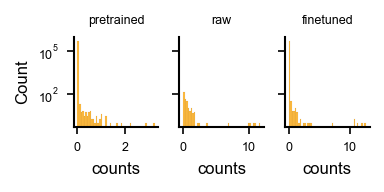

In [12]:
X = pd.concat([
    pd.DataFrame({"data_type": k, "counts": v.ravel()}) 
    for k, v in arr_juncs.items()
    ], 
    ignore_index=True
)

g = sns.displot(
    kind="hist",
    data=X,
    x="counts",
    color="orange",
    col="data_type", col_order=["pretrained","raw","finetuned"],
    bins=50,
    common_bins=False,
    facet_kws=dict(sharex=False),
    height=3.25*cm, aspect=0.7
)

g.set(yscale="log")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.title.set_size(6)
    
g.fig.savefig(os.path.join(FIGS_DIR,"junction_count_distr-hist.pdf"), bbox_inches="tight", dpi=200)

plt.show()

## junction counts vs genomic position

In [13]:
def lookup_junction_counts(
    junction_positions: np.ndarray,  # (4, P) 0-based relative to padded_start
    junction_counts: np.ndarray,     # (P, P, 2*n_tracks)
    raw_tidy: pd.DataFrame,          # donor_pos, acceptor_pos, strand (genomic coords)
    padded_start: int,
    sample_idx: int,
) -> pd.Series:
    """Look up predicted counts for each STAR junction; returns 0 when position not in positions array."""
    donor_pos_map    = {int(p): i for i, p in enumerate(junction_positions[0]) if p >= 0}
    acceptor_pos_map = {int(p): i for i, p in enumerate(junction_positions[1]) if p >= 0}
    donor_neg_map    = {int(p): i for i, p in enumerate(junction_positions[2]) if p >= 0}
    acceptor_neg_map = {int(p): i for i, p in enumerate(junction_positions[3]) if p >= 0}
    n_tracks = junction_counts.shape[2] // 2

    results = []
    for _, row in raw_tidy.iterrows():
        d_rel = int(row["donor_pos"]) - padded_start
        a_rel = int(row["acceptor_pos"]) - padded_start
        if row["strand"] == "+":
            d_idx = donor_pos_map.get(d_rel)
            a_idx = acceptor_pos_map.get(a_rel)
            ch = sample_idx
        else:
            d_idx = donor_neg_map.get(d_rel)
            a_idx = acceptor_neg_map.get(a_rel)
            ch = n_tracks + sample_idx
        results.append(
            float(junction_counts[d_idx, a_idx, ch])
            if (d_idx is not None and a_idx is not None) else 0.0
        )
    return pd.Series(results, index=raw_tidy.index)


tidy = raw_tidy.copy()

# pretrained: use the same fixed track (139) for all rows — pretrained has no sample-specific tracks
tidy["count_pretrained"] = lookup_junction_counts(
    pretrained["junction_positions"], pretrained["junction_counts"],
    raw_tidy, padded_start, sample_idx=139,
)

# finetuned: use per-sample channel (0 for SAMPLES[0], 1 for SAMPLES[1])
sample_to_idx = {s: i for i, s in enumerate(SAMPLES)}
tidy["count_finetuned"] = pd.concat([
    lookup_junction_counts(
        finetuned["junction_positions"], finetuned["junction_counts"],
        grp, padded_start, sample_idx=sample_to_idx[sample_name],
    )
    for sample_name, grp in raw_tidy.groupby("sample", sort=False)
]).reindex(raw_tidy.index)

for name, col in [("pretrained", "count_pretrained"), ("finetuned", "count_finetuned")]:
    n_match = (tidy[col] > 0).sum()
    print(f"  {name}: {n_match}/{len(tidy)} junctions with non-zero predicted count")

display(tidy.head(3))

  pretrained: 571/571 junctions with non-zero predicted count
  finetuned: 571/571 junctions with non-zero predicted count


,sample,donor_pos,acceptor_pos,junction_len,strand,count,count_pretrained,count_finetuned
0,SRR17111303,89105259,89105426,167,-,0.010091,0.000009,0.018677
1,SRR17111303,89131981,89143746,11765,-,0.010091,0.000029,0.015991
2,SRR17111303,89132477,89143746,11269,-,0.010091,0.000027,0.018188


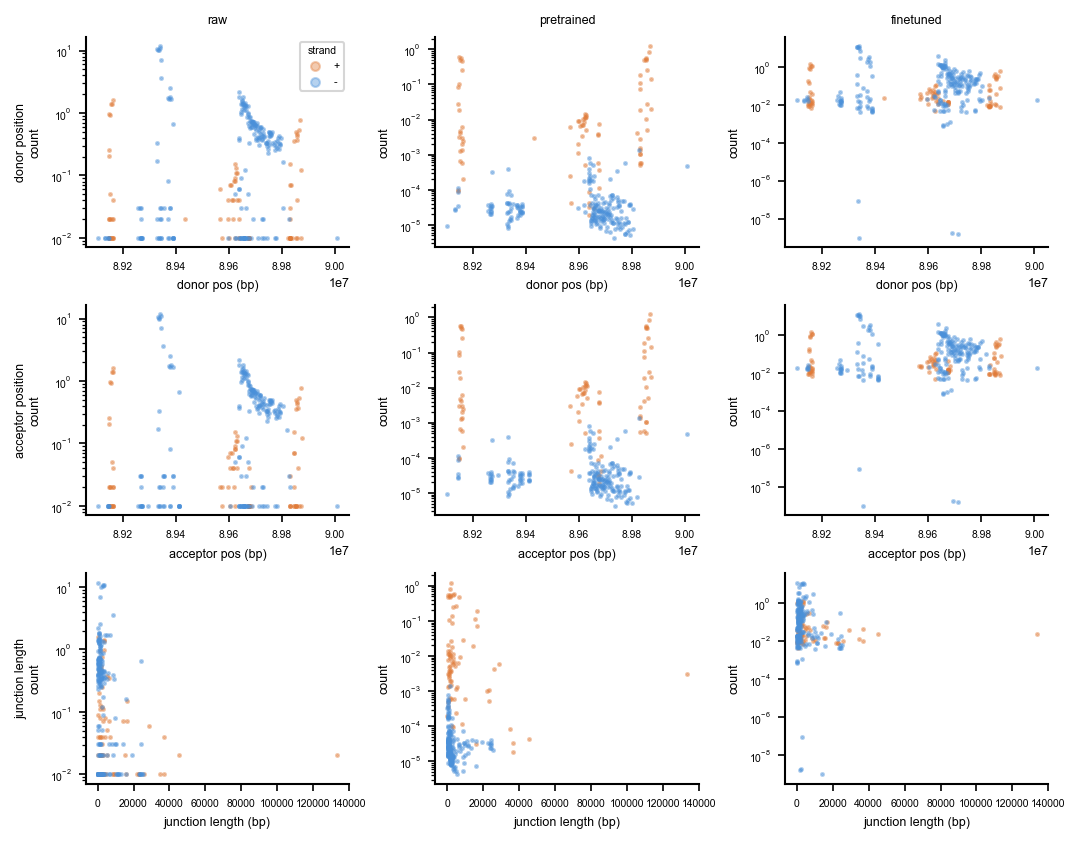

In [14]:
fig, axes = plt.subplots(
    3, 3,
    figsize=(18 * cm, 14 * cm),
    constrained_layout=True,
)

sample_oi = SAMPLES[0]
df = tidy[tidy["sample"] == sample_oi]
data_cols = [("raw", "count"), ("pretrained", "count_pretrained"), ("finetuned", "count_finetuned")]
palette = {"+": "#e07b39", "-": "#4a90d9"}

for col_idx, (name, count_col) in enumerate(data_cols):
    ax_don = axes[0, col_idx]
    ax_acc = axes[1, col_idx]
    ax_len = axes[2, col_idx]

    for strand, grp in df.groupby("strand"):
        c = palette[strand]
        y = grp[count_col].clip(lower=1e-9)
        ax_don.scatter(grp["donor_pos"], y, s=2, alpha=0.4, color=c, rasterized=True, label=strand)
        ax_acc.scatter(grp["acceptor_pos"], y, s=2, alpha=0.4, color=c, rasterized=True)
        ax_len.scatter(grp["junction_len"], y, s=2, alpha=0.4, color=c, rasterized=True)

    ax_don.set_title(name, fontsize=6)
    ax_don.set_xlabel("donor pos (bp)", fontsize=6)
    ax_acc.set_xlabel("acceptor pos (bp)", fontsize=6)
    ax_len.set_xlabel("junction length (bp)", fontsize=6)
    for ax in (ax_don, ax_acc, ax_len):
        ax.set_ylabel("count", fontsize=6)
        ax.tick_params(labelsize=5)
        ax.set_yscale("log")

axes[0, 0].legend(title="strand", fontsize=5, title_fontsize=5, markerscale=3)
row_labels = ["donor position", "acceptor position", "junction length"]
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(f"{label}\ncount", fontsize=6)

fig.savefig(os.path.join(FIGS_DIR, "junction_counts_vs_position-scatter.pdf"), bbox_inches="tight", dpi=200)
plt.show()

In [15]:
df = tidy.copy()

print(f"Total STAR junctions (both samples): {len(df)}")
for name, col in [("pretrained", "count_pretrained"), ("finetuned", "count_finetuned")]:
    n_match = (df[col] > 0).sum()
    print(f"  {name}: {n_match} non-zero predicted")

display(df.head(3))

Total STAR junctions (both samples): 571
  pretrained: 571 non-zero predicted
  finetuned: 571 non-zero predicted


,sample,donor_pos,acceptor_pos,junction_len,strand,count,count_pretrained,count_finetuned
0,SRR17111303,89105259,89105426,167,-,0.010091,0.000009,0.018677
1,SRR17111303,89131981,89143746,11765,-,0.010091,0.000029,0.015991
2,SRR17111303,89132477,89143746,11269,-,0.010091,0.000027,0.018188


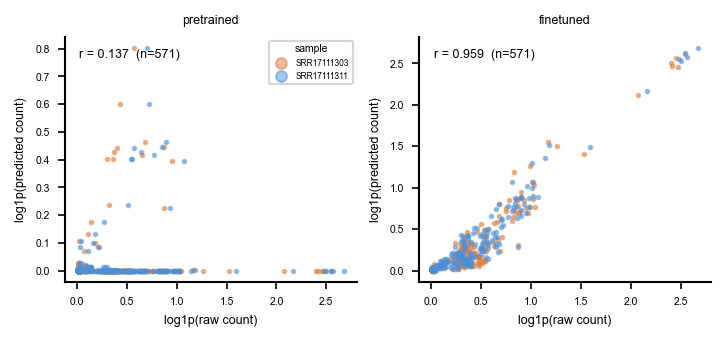

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 5.5 * cm), constrained_layout=True)

palette_sample = {s: c for s, c in zip(SAMPLES, ["#e07b39", "#4a90d9"])}

for ax, (label, y_col) in zip(axes, [("pretrained", "count_pretrained"), ("finetuned", "count_finetuned")]):
    all_true = np.log1p(df["count"].values)
    all_pred = np.log1p(df[y_col].values)
    r, _ = pearsonr(all_true, all_pred)

    for sample_name, grp in df.groupby("sample"):
        ax.scatter(
            np.log1p(grp["count"]),
            np.log1p(grp[y_col]),
            s=3, alpha=0.5,
            color=palette_sample[sample_name],
            label=sample_name,
            rasterized=True,
        )

    ax.set_title(label, fontsize=6)
    ax.set_xlabel("log1p(raw count)", fontsize=6)
    ax.set_ylabel(f"log1p(predicted count)", fontsize=6)
    ax.tick_params(labelsize=5)
    ax.text(0.05, 0.95, f"r = {r:.3f}  (n={len(df)})", transform=ax.transAxes,
            ha="left", va="top", fontsize=6)

axes[0].legend(title="sample", fontsize=4, title_fontsize=5, markerscale=3)

plt.show()

In [17]:
# Combined Pearson r across both samples using pre-computed columns in tidy
# pretrained: same track (139) for all rows; finetuned: per-sample channels
for label, col in [("pretrained", "count_pretrained"), ("finetuned", "count_finetuned")]:
    all_true = np.log1p(tidy["count"].values)
    all_pred = np.log1p(tidy[col].values)
    r_combined, _ = pearsonr(all_true, all_pred)
    print(f"{label}  combined r = {r_combined:.3f}")
    for sample_name, grp in tidy.groupby("sample"):
        r_s, _ = pearsonr(np.log1p(grp["count"].values), np.log1p(grp[col].values))
        print(f"  {sample_name} (n={len(grp)}): r = {r_s:.3f}")
    print()

pretrained  combined r = 0.137
  SRR17111303 (n=280): r = 0.101
  SRR17111311 (n=291): r = 0.172

finetuned  combined r = 0.959
  SRR17111303 (n=280): r = 0.953
  SRR17111311 (n=291): r = 0.965

